# Decision Trees

Classifying the Breast Cancer Wisconsin dataset using a Decision Tree Classifier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

## Load Data

In [2]:
cancer = datasets.load_breast_cancer()
X = cancer.data
y = cancer.target
print(X.shape, y.shape)
print("1 benign:", sum(y), "|", "0 malignant:", len(y) - sum(y))

(569, 30) (569,)
1 benign: 357 | 0 malignant: 212


In [3]:
df = pd.DataFrame(X, columns=cancer.feature_names)
df['class'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,class
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Train-Test Split

Decision trees are not distance-based, so feature scaling is not required.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (455, 30) Test shape: (114, 30)


## Baseline Decision Tree

In [5]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Tree depth:", dt.get_depth())
print("Number of leaves:", dt.get_n_leaves())

Accuracy: 0.9122807017543859
Tree depth: 7
Number of leaves: 19


## Evaluation

              precision    recall  f1-score   support

   malignant       0.85      0.93      0.89        42
      benign       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



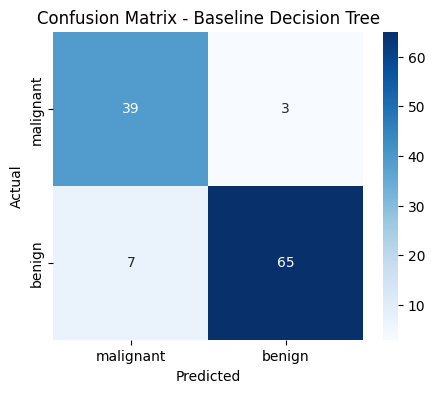

In [6]:
cm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, target_names=cancer.target_names))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline Decision Tree')
plt.show()

## Visualizing the Tree

The unpruned tree tends to be deep and overfit — visualize the top few levels only for readability.

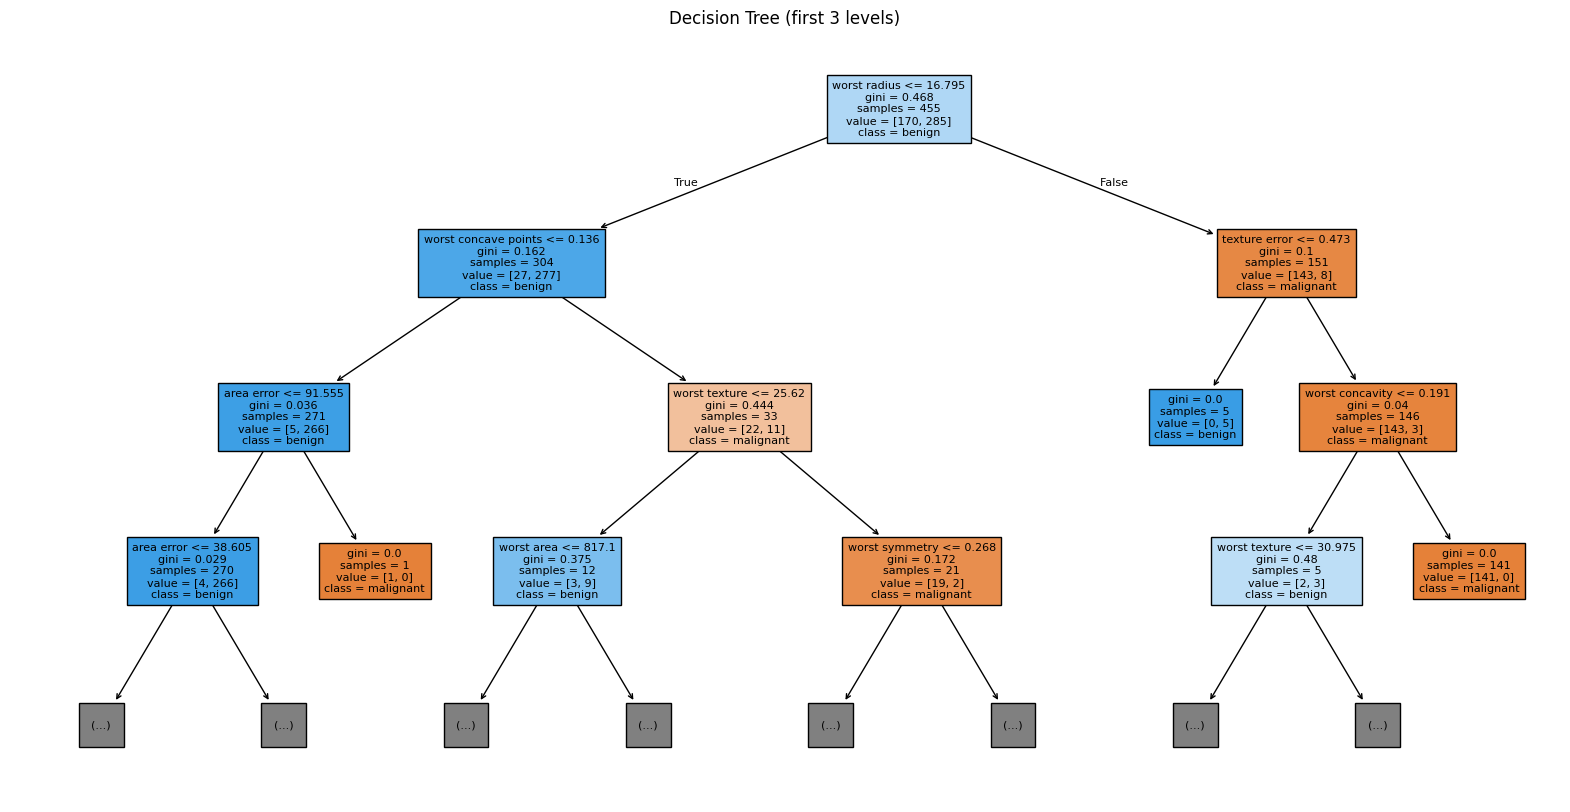

In [7]:
plt.figure(figsize=(20,10))
plot_tree(dt, max_depth=3, feature_names=cancer.feature_names,
          class_names=cancer.target_names, filled=True, fontsize=8)
plt.title('Decision Tree (first 3 levels)')
plt.show()

## Feature Importance

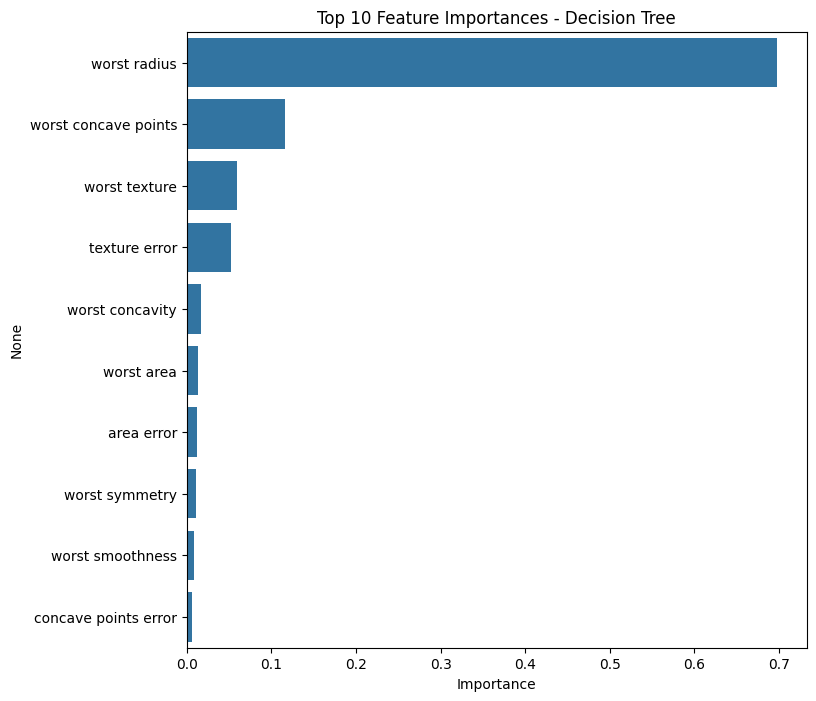

worst radius            0.697811
worst concave points    0.116083
worst texture           0.058881
texture error           0.052661
worst concavity         0.016325
worst area              0.012678
area error              0.012085
worst symmetry          0.010733
worst smoothness        0.008452
concave points error    0.006261
dtype: float64

In [8]:
importances = pd.Series(dt.feature_importances_, index=cancer.feature_names).sort_values(ascending=False)

plt.figure(figsize=(8,8))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index)
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances - Decision Tree')
plt.show()

importances.head(10)

## Overfitting Check: Train vs Test Accuracy by Depth

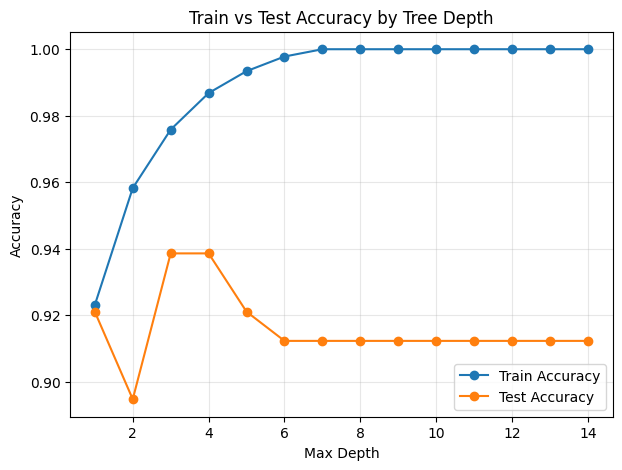

In [9]:
depths = range(1, 15)
train_scores, test_scores = [], []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(7,5))
plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
plt.plot(depths, test_scores, marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Hyperparameter Tuning with GridSearchCV

In [10]:
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.9384615384615385


## Final Tuned Model

Test accuracy (tuned model): 0.9385964912280702

              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



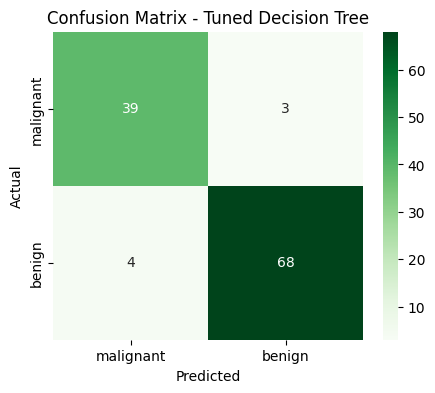

In [11]:
best_dt = grid.best_estimator_
y_pred_best = best_dt.predict(X_test)

print("Test accuracy (tuned model):", metrics.accuracy_score(y_test, y_pred_best))
print()
print(classification_report(y_test, y_pred_best, target_names=cancer.target_names))

cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Decision Tree')
plt.show()

## ROC Curve & AUC

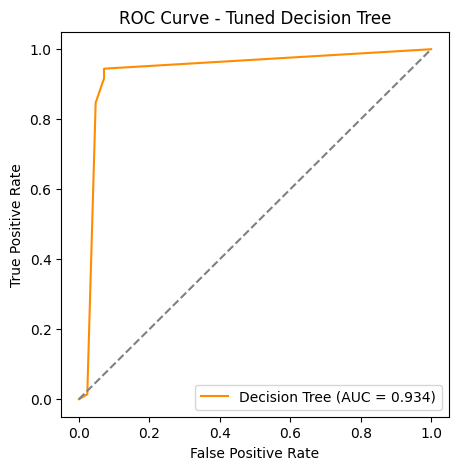

In [12]:
y_proba = best_dt.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {auc_score:.3f})', color='darkorange')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Decision Tree')
plt.legend()
plt.show()

## Summary

- Dataset: Breast Cancer Wisconsin (569 samples, 30 features, binary target: malignant / benign).
- No feature scaling needed — decision trees split on raw feature thresholds.
- Baseline unpruned tree overfits (near-perfect train accuracy, lower test accuracy).
- Visualized the top 3 levels of the tree and ranked feature importances (worst area / worst concave points typically dominate).
- The train-vs-test-accuracy-by-depth plot shows the overfitting point — test accuracy plateaus/drops as depth grows unchecked.
- Tuned `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion` with `GridSearchCV` (5-fold CV).
- Evaluated the final model with accuracy, precision/recall/F1, confusion matrix, and ROC-AUC.